In [ ]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
dt = ds.Coco("/home/wanderer2414/coco2017/")

loading annotations into memory...


In [ ]:
# import MyRCNN
# import torch
# model = MyRCNN.Model(device=torch.device("cpu"))
# model.model.load_state_dict(torch.load("bbx.pth", map_location="cpu"))

In [ ]:
import MyRCNN
import torch
model = MyRCNN.Model(device=torch.device("cuda"))
model.train(dt)

Here
Out
Here
Out
Here


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.02 GiB. GPU 0 has a total capacity of 11.63 GiB of which 10.76 GiB is free. Including non-PyTorch memory, this process has 878.00 MiB memory in use. Of the allocated memory 646.94 MiB is allocated by PyTorch, and 107.06 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

from torch import stack
import torch
from torch import Tensor
def nms(boxes: Tensor)->Tensor:
    N = boxes.shape[0]
    rows, cols = torch.meshgrid(torch.arange(N, device=boxes.device), torch.arange(N, device=boxes.device), indexing='ij')
    
    boxes1 = boxes.unsqueeze(1).expand(N, N, 4)
    boxes2 = boxes.unsqueeze(0).expand(N, N, 4)
    x1 = torch.max(boxes1[:, :, 0], boxes2[:, :, 0])
    x2 = torch.min(boxes1[:, :, 2], boxes2[:, :, 2])
    w = x2 - x1
    del x1, x2
    y1 = torch.max(boxes1[:, :, 1], boxes2[:, :, 1])
    y2 = torch.min(boxes1[:, :, 3], boxes2[:, :, 3])
    h = y2-y1
    del y2, y1
    s = ((boxes[:, 2]-boxes[:, 0])*(boxes[:, 3] - boxes[:, 1]))
    s = s.unsqueeze(1).expand(N, N) + s.unsqueeze(0).expand(N, N)
    intersect = w*h
    IoU = intersect/(s - intersect)
    IoU = IoU * (rows>cols)
    cond = IoU > 0.8
    indices = (cond.any(dim=1).logical_not())
    
    return boxes[indices]

def mode_pool2d(x, kernel_size=3, stride=1, padding=0) -> Tensor:
    if padding > 0:
        x = torch.nn.functional.pad(x, (padding, padding, padding, padding), mode="reflect")
    B, C, H, W = x.shape
    patches = torch.nn.functional.unfold(x, kernel_size=kernel_size, stride=stride)
    patches = patches.view(B, C, kernel_size * kernel_size, -1)
    median = patches.mode(dim=2).values
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    return median.view(B, C, H_out, W_out)

class MaxReLU(torch.nn.Module):
    def __init__(self, kernel_size: int, stride: int = 1, padding: int = 0, slope: float = 0.01) -> None:
        super().__init__()
        self.slope = slope
        self.padding = padding
        self.stride = stride
        self.kernel_size = kernel_size
        self.mid = (self.kernel_size+1) * (self.kernel_size//2)
    def forward(self, x: Tensor) -> Tensor:
        if self.padding > 0:
            x = torch.nn.functional.pad(x, (self.padding, self.padding, self.padding, self.padding), mode="reflect")
        B, C, H, W = x.shape
        patches = torch.nn.functional.unfold(x, kernel_size=self.kernel_size, stride=self.stride)
        patches = patches.view(B, C, self.kernel_size * self.kernel_size, -1)
        M = patches.max(dim=-2, keepdim=True).values
        error = patches.std(dim=-2, keepdim=True, unbiased=False)/10
        mid = patches[:, :, self.mid:self.mid+1, :]
        output = torch.where(mid >= M-error, M, self.slope*mid)
        H_out = (H - self.kernel_size) // self.stride + 1
        W_out = (W - self.kernel_size) // self.stride + 1
        return output.view(B, C, H_out, W_out)

torch.Size([117, 4])
Min: -0.9257932901382446, Max: 4.222218036651611


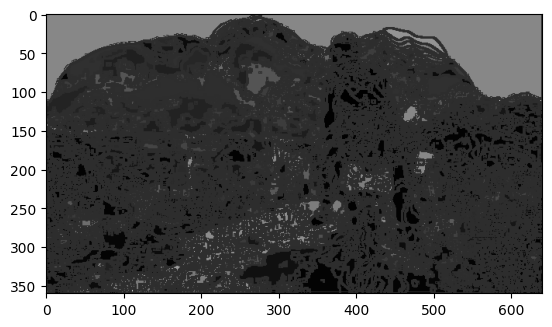

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from dataset import TensorToImg, ImgToTensor
x = dt.getTrainTensor(0).to(device=torch.device("cuda"))
# x = x[:, :, 0:350, 250:600]
mask, color, result = model.model(x)
boxes = result[1][:, :, 1:].squeeze(0)
print(boxes.shape)
# boxes = nms(boxes)
# for box in boxes:
#     x1, y1, x2, y2 = box.detach().cpu().numpy()
#     rect = pat.Rectangle((x1, y1), x2, y2, facecolor='none', edgecolor='red')
#     plt.subplot().add_patch(rect)
B, C, H, W = x.shape
x=  (x*255/16).round()*16/256
x = mode_pool2d(x, 11, 1, 5)
prep = model.model.color.prepare(x)
down1 = model.model.color.downgrade(prep)
down2 = model.model.color.downgrade(down1)
down3 = model.model.color.downgrade(down2)
down4 = model.model.color.downgrade(down3)
down5 = model.model.color.downgrade(down4)

width1 = model.model.color.width(down1)
width2 = model.model.color.width(down2)
width3 = model.model.color.width(down3)
width4 = model.model.color.width(down4)
width5 = model.model.color.width(down5)

height1 = model.model.color.height(down1)
height2 = model.model.color.height(down2)
height3 = model.model.color.height(down3)
height4 = model.model.color.height(down4)
height5 = model.model.color.height(down5)
mix1 = stack([width1, height1], dim=1).reshape(1, 32, width1.shape[-2], width1.shape[-1])
mix2 = stack([width2, height2], dim=1).reshape(1, 32, width2.shape[-2], width2.shape[-1])
mix3 = stack([width3, height3], dim=1).reshape(1, 32, width3.shape[-2], width3.shape[-1])
mix4 = stack([width4, height4], dim=1).reshape(1, 32, width4.shape[-2], width4.shape[-1])
mix5 = stack([width5, height5], dim=1).reshape(1, 32, width5.shape[-2], width5.shape[-1])
# print(model.model.color.downgrade[0].weight[0])
# x = down1[:, 0:1, :, :]
# x = height4[:, 0:1, :, :]
x = down1[:, 2:3, :, :]
# x = mx(x)
x = x.repeat(1, 3, 1, 1)
print(f"Min: {x.min()}, Max: {x.max()}")
x = x-x.min()
x = x/x.max()
# ImgWrite("filtercolor.png", TensorToImg(x.detach().cpu()))
plt.imshow(TensorToImg(x.detach().cpu()))

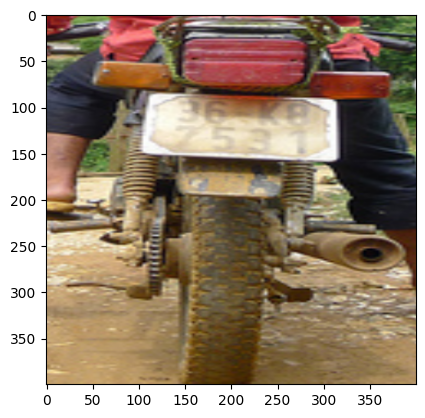

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from torchvision.ops import roi_align
from dataset import TensorToImg, ImgToTensor
i = 0
x = dt.getTrainTensor(i).to(device=torch.device("cuda"))
label = dt.getTrainLabel(i).to(device=torch.device("cuda"))
mask, color, result = model.model(x)
boxes = label[:, :-1]
x = roi_align(x, [boxes], (400, 400))
cls = model.cls(mask, color, boxes)
plt.imshow(TensorToImg(x.detach().cpu()))
cls_label = label[:, -1]
# print(cls_label)
# print(cls_label, cls[cls_label.long()])